In [1]:
# ==================== INSTALL & SETUP ====================
%run CleanData.ipynb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Dense, Flatten
from tensorflow.keras.layers import LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
# ==================== DATA PREPARATION ====================
# Reshape for sequence input
X_train_seq = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_seq = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)


In [3]:
# ==================== BUILD MODEL ====================
model = Sequential([
    # CNN block
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),

    # Bidirectional LSTM
    Bidirectional(LSTM(64, return_sequences=False)),

    # Fully connected
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])


c:\Users\plui0\anaconda3\envs\tfcpu\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# ==================== COMPILE MODEL ====================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 129, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 129, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,334 (294.27 KB)

 Trainable params: 75,206 (293.77 KB)

 Non-trainable params: 128 (512.00 B)

In [5]:
# ==================== TRAIN MODEL ====================
# Split off 15% of training set for validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_seq, y_train_cat, test_size=0.15, random_state=42
)

# Train the model using training and validation sets
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_final, y_train_final,
    epochs=30,
    batch_size=128,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)



Epoch 1/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step - accuracy: 0.8141 - loss: 0.9162 - val_accuracy: 0.9037 - val_loss: 0.3162
Epoch 2/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.9104 - loss: 0.4148 - val_accuracy: 0.8942 - val_loss: 0.3147
Epoch 3/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.9365 - loss: 0.3009 - val_accuracy: 0.9387 - val_loss: 0.2014
Epoch 4/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9499 - loss: 0.2428 - val_accuracy: 0.9370 - val_loss: 0.2234
Epoch 5/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9544 - loss: 0.2271 - val_accuracy: 0.9600 - val_loss: 0.1250
Epoch 6/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9591 - loss: 0.2026 - val_accuracy: 0.9593 - val_loss: 0.1333
Epoch 7/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.9633 - loss: 0.1813 - val_accuracy: 0.9616 - val_loss: 0.1236
Epoch 8/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 38s 58ms/step - accuracy: 0.9669 - loss: 0.1641 - 

In [6]:
# ==================== EVALUATE MODEL ====================
from sklearn.metrics import classification_report, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Evaluate the model
loss, accuracy = model.evaluate(X_test_seq, y_test_cat)
print(f"Test Accuracy: {accuracy:.4f}")

# Predict class probabilities and labels
y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.astype(int)

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred))
print("Recall (macro):", recall_score(y_true, y_pred, average='macro'))



776/776 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9523 - loss: 0.1494
Test Accuracy: 0.9677
776/776 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     18952
           1       0.80      0.72      0.76       556
           2       0.93      0.94      0.94      1448
           3       0.83      0.78      0.80       162
           4       0.98      0.98      0.98      1608
           5       0.97      0.87      0.91      2077

    accuracy                           0.97     24803
   macro avg       0.91      0.88      0.90     24803
weighted avg       0.97      0.97      0.97     24803

Recall (macro): 0.8792702756423626


776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step


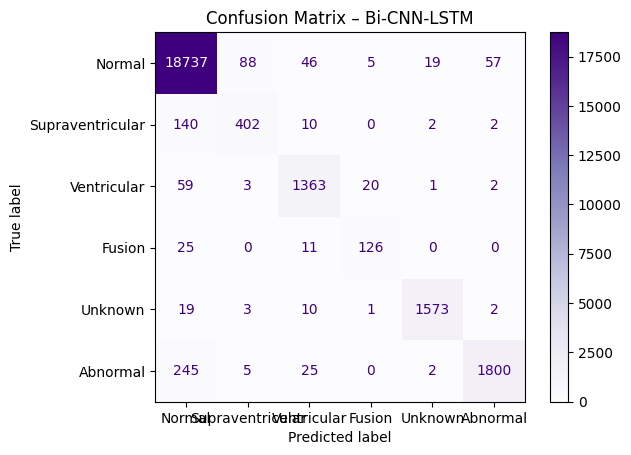

In [7]:
# ==================== CONFUSION MATRIX ====================
# Predict class labels from the test set
y_pred_prob = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_prob, axis=1)

# Create and display confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown', 'Abnormal']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Purples')
plt.title("Confusion Matrix – Bi-CNN-LSTM")
plt.show()


C:\Users\plui0\AppData\Local\Temp\ipykernel_1972\1012050575.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('plasma', num_classes)


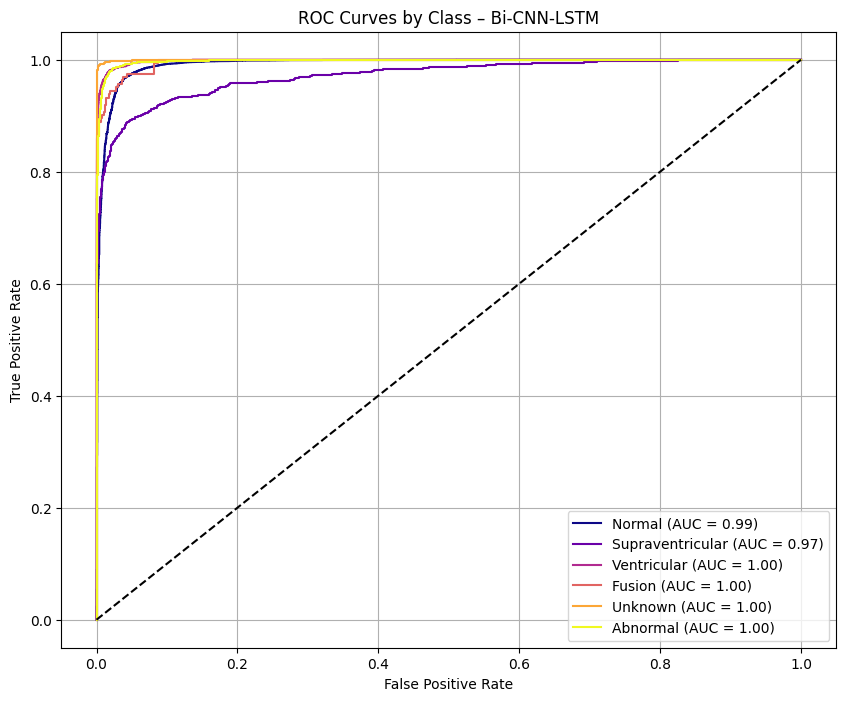

In [8]:
# ==================== ROC & AUC ====================
# Binarize test labels
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('plasma', num_classes)
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{labels[i]} (AUC = {roc_auc[i]:.2f})", color=colors(i))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves by Class – Bi-CNN-LSTM")
plt.legend(loc='lower right')
plt.grid(True)
plt.show()